<a href="https://colab.research.google.com/github/Tejamanikanta03/Stats_analysis/blob/main/E_Commerce_A_B_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **E-Commerce A/B Testing: Analyzing the Impact of a New Checkout Feature**

* **Project Goal** : The objective of this project is to determine whether a newly designed digital feature at checkout drives a statistically significant increase in the conversion rate compared to the existing checkout flow. We will clean the experiment data, compute the relative uplift, and perform a Two-Proportion Z-Test to provide a final, data-backed business recommendation.

**Importing Essential Libraries**
* **pandas  & numpy** → for data manipulation and numerical operations
* **matplotlib & seaborn** → for data visualization and EDA
* **statsmodels** → for performing statistical hypothesis testing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

**Loading and Inspecting the Dataset**

The dataset contains the following key columns:

* **user_id**: Unique identifier for each visitor.

* **group**: The experiment group (control or treatment).

* **landing_page**: The page the user actually saw (old_page or new_page).

* **converted**: The binary outcome where 1 means the user purchased, and 0 means they abandoned checkout.

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colabs/ab_data.csv')

print(f"Total rows in raw data: {df.shape[0]}")
display(df.head())
df.info()

Total rows in raw data: 294478


,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


**The Data Cleaning Process**

In digital experiments, logging errors or routing glitches can occur. Our primary cleaning goal is to ensure the integrity of our test groups.

1. **Remove Mismatches**: We must remove users in the control group who accidentally saw the new_page, and users in the treatment group who saw the old_page.

2. **Remove Duplicates**: To ensure our statistical tests assume independent observations, we will drop duplicate user_id entries so each user only casts one "vote" in our conversion metrics.

In [ ]:
mismatch = df[((df['group'] == 'control') & (df['landing_page'] == 'new_page')) |
              ((df['group'] == 'treatment') & (df['landing_page'] == 'old_page'))]

df_clean = df.drop(mismatch.index)


df_clean = df_clean.drop_duplicates(subset='user_id')

print(f"Rows after cleaning: {df_clean.shape[0]}")
print(f"Total rows removed: {df.shape[0] - df_clean.shape[0]}")

Rows after cleaning: 290584
Total rows removed: 3894


**Experiment Setup & Traffic Split Verification**

A valid A/B test requires an unbiased sample. We will define our control and variant groups and check the traffic split. Ideally, the routing system should have split the traffic roughly 50/50. If the split is heavily skewed, it could indicate a deeper systemic error in the experiment's execution.

In [ ]:
split_counts = df_clean['group'].value_counts()
split_percentages = df_clean['group'].value_counts(normalize=True) * 100

traffic_split = pd.DataFrame({'Total Users': split_counts, 'Percentage (%)': split_percentages})
display(traffic_split)

,Total Users,Percentage (%)
group,,
treatment,145310,50.006194
control,145274,49.993806


**Calculating Conversion Rates and Uplift**

we calculate the core metrics.
Conversion Rate: The formula is

$Conversion = \frac{Converted \: Users}{Total \: Users}$

Relative Uplift: This measures the percentage growth (or decline) caused by the new feature relative to the old feature's baseline.

In [ ]:
conversion_stats = df_clean.groupby('group')['converted'].agg(['count', 'sum', 'mean'])
conversion_stats.columns = ['Total Users', 'Converted Users', 'Conversion Rate']

control_rate = conversion_stats.loc['control', 'Conversion Rate']
treatment_rate = conversion_stats.loc['treatment', 'Conversion Rate']

uplift = (treatment_rate - control_rate) / control_rate

display(conversion_stats)
print(f"\nRelative Uplift: {uplift:.2%}")

,Total Users,Converted Users,Conversion Rate
group,,,
control,145274,17489,0.120386
treatment,145310,17264,0.118808



Relative Uplift: -1.31%


**Exploratory Data Analysis (EDA)**: Conversion Dashboard

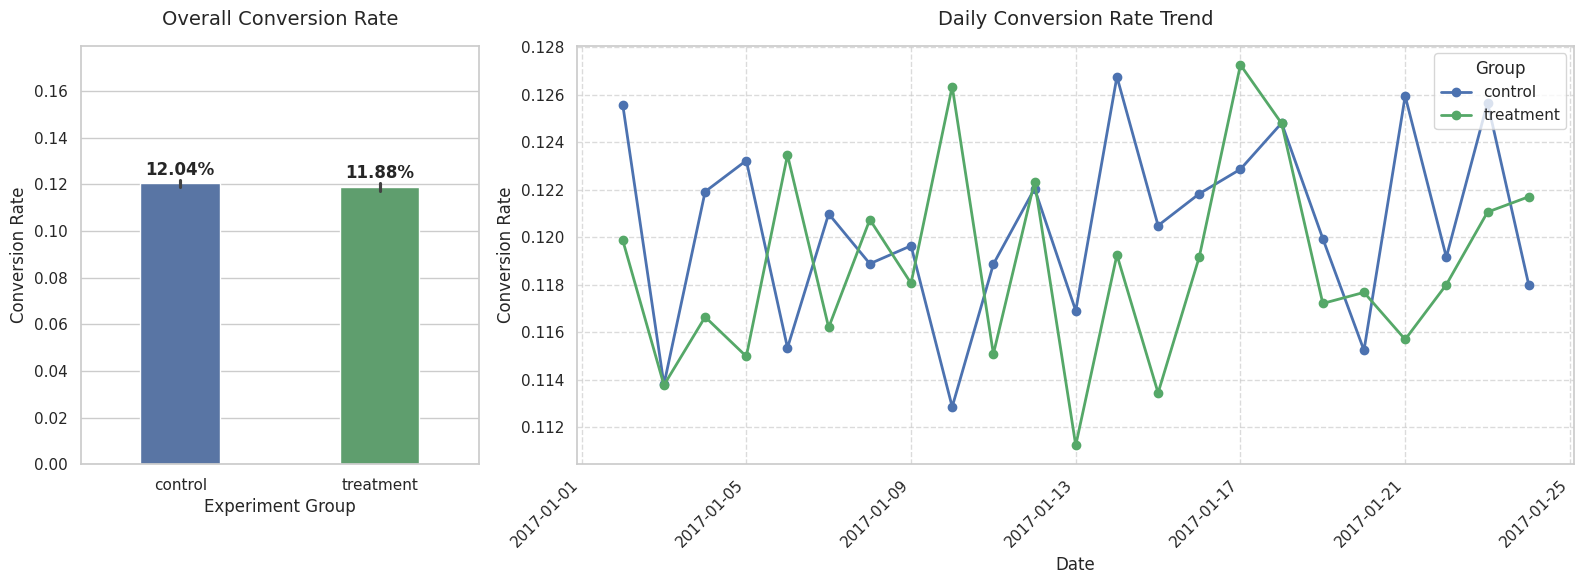

In [ ]:
df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])
df_clean['date'] = df_clean['timestamp'].dt.date

fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [1, 2.5]})

# --- PLOT 1: Overall Bar Chart ---
sns.barplot(x='group', y='converted', data=df_clean, errorbar=('ci', 95),
            ax=axes[0], palette=['#4C72B0', '#55A868'], width=0.4)

axes[0].set_title('Overall Conversion Rate', fontsize=14, pad=15)
axes[0].set_ylabel('Conversion Rate', fontsize=12)
axes[0].set_xlabel('Experiment Group', fontsize=12)

max_val = df_clean['converted'].mean() * 1.5
axes[0].set_ylim(0, max_val)

for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.2%}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center',
                     xytext=(0, 10), textcoords='offset points',
                     fontweight='bold')

# --- PLOT 2: Daily Trend Line Chart ---
daily_conversion = df_clean.groupby(['date', 'group'])['converted'].mean().unstack()

daily_conversion.plot(ax=axes[1], marker='o', linewidth=2, color=['#4C72B0', '#55A868'])
axes[1].set_title('Daily Conversion Rate Trend', fontsize=14, pad=15)
axes[1].set_ylabel('Conversion Rate', fontsize=12)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].legend(title='Group', loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

- **The Overall Bar Chart (Left)**: The conversion rates for both the Control (old checkout) and Treatment (new checkout) are practically neck-and-neck, hovering right around that 12% mark. The little error bars at the top also overlap significantly. In A/B testing, overlapping error bars are usually our first visual clue that there isn't a massive, game-changing difference between the two groups.

- **The Daily Trend (Right)**: Looking at the line chart, the two lines are pretty much tangled together. We don't see the Treatment line breaking away and consistently staying above the Control line. It just looks like normal, day-to-day random noise. There is also no massive spike at the beginning, meaning we didn't even get a temporary "novelty effect" from the new design.

**Defining Hypotheses & Running the Z-TestBecause**

we are comparing the proportions of two independent, categorically divided groups (converted vs. not converted), the **Two-Proportion Z-Test** is the correct statistical method.

* **Null Hypothesis**($H_0$):
 $p_{control} = p_{treatment}$
 (The new checkout feature has no effect on the conversion rate).

 * **Alternative Hypothesis**($H_a$):
  $p_{control} \neq p_{treatment}$ (The new checkout feature significantly alters the conversion rate).We will evaluate this at a standard significance level of $\alpha = 0.05$.

In [ ]:
successes = [conversion_stats.loc['control', 'Converted Users'],
             conversion_stats.loc['treatment', 'Converted Users']]
nobs = [conversion_stats.loc['control', 'Total Users'],
        conversion_stats.loc['treatment', 'Total Users']]

# Run the Z-test
z_stat, p_val = proportions_ztest(successes, nobs)

print(f"Z-Statistic: {z_stat:.4f}")
print(f"P-Value: {p_val:.4f}")

Z-Statistic: 1.3109
P-Value: 0.1899


**Z-Statistic (1.31)**: This is a score that measures how different the two groups are. A score of 1.31 is relatively small, meaning the new checkout feature didn't move the needle much compared to the old one.

**P-Value (0.1899)**: This is the "luck" factor. A p-value of 0.1899 means there is an 18.99% chance that any difference we see is just random luck.

With a P-value of $0.1899$, which is significantly greater than our $\alpha$ threshold of $0.05$, we **fail to reject the Null Hypothesis**.

**Calculating Confidence Intervals**

The p-value tells us if the result is statistically significant, but the Confidence Interval tells us the practical magnitude of the conversion rate. We will calculate the 95% bounds to see the probable range of the true population conversion rate for both designs.

In [ ]:
# Calculate 95% Confidence Intervals
(lower_con, lower_treat), (upper_con, upper_treat) = proportion_confint(successes, nobs=nobs, alpha=0.05)

print(f"Control 95% CI:   [{lower_con:.4f}, {upper_con:.4f}]")
print(f"Treatment 95% CI: [{lower_treat:.4f}, {upper_treat:.4f}]")

Control 95% CI:   [0.1187, 0.1221]
Treatment 95% CI: [0.1171, 0.1205]


**Old Checkout (Control)**: We are highly confident the true conversion rate is between 11.87% and 12.21%.

**New Checkout (Treatment)**: We are highly confident the true conversion rate is between 11.71% and 12.05%.

Not only do these ranges overlap heavily (meaning there is no clear winner), but the new checkout's maximum potential ($12.05\%$) is lower than the old checkout's maximum potential ($12.21\%$). This confirms the new feature is definitely not an improvement, and is actually trending slightly worse.

## **Data-Driven Action Plan**

The analysis shows that the new checkout feature did not improve conversions. Statistical evidence indicates that its performance is not significantly better than the old version, and it may even be slightly worse.

Based on this, the best decision is to avoid launching the new feature since it does not provide enough benefit to justify additional engineering and maintenance costs. The experiment should be stopped, and all users should be directed back to the original checkout page.
